In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("data/raw/fbref_player_shooting_stats_2026_raw.csv", skiprows=1)
print("Raw shape:", df.shape)
df.head()

Raw shape: (1039, 19)


,Rk,Player,Pos,Squad,Age,Born,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK,PKatt,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,3,1,33.3,3.55,1.18,0.0,0.0,0,0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,1,2,1,50.0,2.00,1.00,0.5,1.0,0,0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,Matches,bff15d74


In [3]:
df = df.drop(columns=["-9999", "Matches", "Rk"], errors="ignore")

for col in ["90s", "Gls", "Sh", "SoT", "Sh/90", "SoT/90"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Squad"] = df["Squad"].str.replace(r"^[a-z]{2}\s+", "", regex=True)

print("Missing values in Sh/90:", df["Sh/90"].isna().sum())

Missing values in Sh/90: 0


In [4]:
played = df[df["90s"] >= 1].copy()

forwards    = played[played["Pos"] == "FW"]
midfielders = played[played["Pos"] == "MF"]
print("Forwards available:", len(forwards), "| Midfielders available:", len(midfielders))

fw_sample = forwards.sample(n=80, random_state=42)["Sh/90"]
mf_sample = midfielders.sample(n=80, random_state=42)["Sh/90"]

Forwards available: 99 | Midfielders available: 254


In [5]:
print("--- DESCRIPTIVE STATISTICS (Sh/90) ---")
print("FORWARDS    n=%d  mean=%.3f  median=%.3f  std=%.3f"
      % (len(fw_sample), fw_sample.mean(), fw_sample.median(), fw_sample.std()))
print("MIDFIELDERS n=%d  mean=%.3f  median=%.3f  std=%.3f"
      % (len(mf_sample), mf_sample.mean(), mf_sample.median(), mf_sample.std()))

--- DESCRIPTIVE STATISTICS (Sh/90) ---
FORWARDS    n=80  mean=2.165  median=2.040  std=1.231
MIDFIELDERS n=80  mean=1.264  median=1.010  std=1.006


C:\Users\User\AppData\Local\Temp\ipykernel_44940\2658951229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Position", y="Shots per 90", palette="Set2")


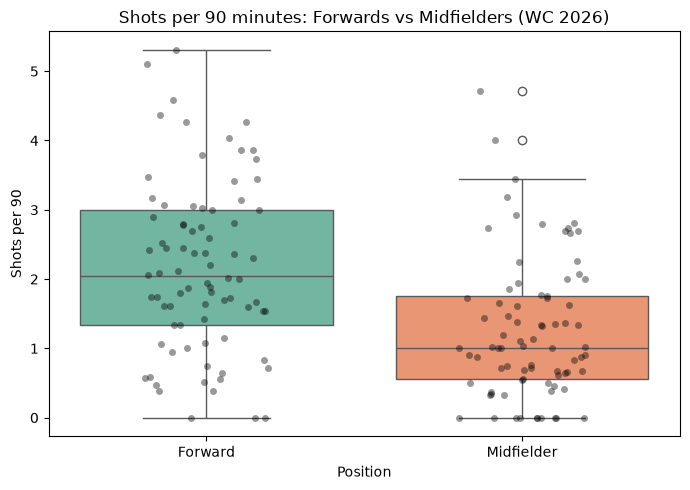

In [6]:
plot_df = pd.DataFrame({
    "Shots per 90": pd.concat([fw_sample, mf_sample], ignore_index=True),
    "Position": ["Forward"]*len(fw_sample) + ["Midfielder"]*len(mf_sample)
})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x="Position", y="Shots per 90", palette="Set2")
sns.stripplot(data=plot_df, x="Position", y="Shots per 90", color="black", alpha=0.4, jitter=0.2)
plt.title("Shots per 90 minutes: Forwards vs Midfielders (WC 2026)")
plt.tight_layout()
plt.savefig("attacking_boxplot.png", dpi=150)
plt.show()

In [7]:
print("--- 95% CONFIDENCE INTERVALS ---")
for name, s in [("Forwards", fw_sample), ("Midfielders", mf_sample)]:
    ci = stats.t.interval(0.95, len(s)-1, loc=s.mean(), scale=stats.sem(s))
    print("%s: [%.3f, %.3f]" % (name, ci[0], ci[1]))

--- 95% CONFIDENCE INTERVALS ---
Forwards: [1.891, 2.439]
Midfielders: [1.040, 1.488]


In [8]:
t_stat, p_value = stats.ttest_ind(fw_sample, mf_sample, equal_var=False)
print("--- WELCH TWO-SAMPLE T-TEST ---")
print("t-statistic = %.3f" % t_stat)
print("p-value     = %.5f" % p_value)

alpha = 0.05
if p_value < alpha:
    print("Decision: p < 0.05  ->  REJECT H0. The difference IS statistically significant.")
else:
    print("Decision: p >= 0.05 ->  FAIL to reject H0. No significant difference.")

--- WELCH TWO-SAMPLE T-TEST ---
t-statistic = 5.071
p-value     = 0.00000
Decision: p < 0.05  ->  REJECT H0. The difference IS statistically significant.


## 9. Interpretation

Forwards recorded a higher average number of shots per 90 minutes (mean = 2.17) than midfielders (mean = 1.26) in our sample of 80 players per group. The 95% confidence intervals for the two groups do not overlap (Forwards: [1.89, 2.44]; Midfielders: [1.04, 1.49]), and Welch's two-sample t-test returned t = 5.07 with a p-value below 0.001, well under the 0.05 significance level.

We therefore reject the null hypothesis and conclude that, during the FIFA World Cup 2026, forwards took significantly more shots per 90 minutes than midfielders. This aligns with football intuition: forwards play closer to goal and are the primary shot-takers, while midfielders focus more on creating and controlling play.